In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy.stats import spearmanr
from scipy.stats import linregress


plt.style.use('tableau-colorblind10')
plt.rcParams.update({'font.size': 14, 'font.family':'Arial'})

### Get all VMGC species with at least 5 genomes per species

In [2]:
df = pd.read_csv('VMGC_db_build/VMGC_orig_files/VMGC_prokaryote_MAG.info', sep='\t')
sgb_info = pd.read_csv('VMGC_db_build/VMGC_orig_files/VMGC_prokaryote_SGB.info', sep='\t', index_col=0)
sgb_to_species = sgb_info['Species']
df['species'] = df['Species-level_genomic_bin_(95%_ANI)'].map(sgb_to_species)

In [3]:
sgb_info

,Representative_genome_ID,Number_of_genomes,Kingdom,Phylum,Class,Order,Family,Genus,Species,Taxonomic_level,Cultured
SGB_ID,,,,,,,,,,,
SGB001,SRR17284223.mbin.1,1544,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Lactobacillus,Lactobacillus iners,Species,Cultured (women vagina)
SGB002,GCF_001562845.1,764,Bacteria,Actinomycetota,Coriobacteriia,Coriobacteriales,Atopobiaceae,Fannyhessea,Fannyhessea vaginae,Species,Cultured (women vagina)
SGB003,GCF_001553395.1,664,Bacteria,Bacillota_C,Negativicutes,Veillonellales,Megasphaeraceae,Megasphaera,Megasphaera lornae,Species,Cultured (women vagina)
SGB004,ERR10897722.mbin.1,586,Bacteria,Actinomycetota,Actinomycetia,Actinomycetales,Bifidobacteriaceae,Bifidobacterium,Bifidobacterium vaginale,Species,Cultured (women vagina)
SGB005,MG1112.mbin.9,562,Bacteria,Actinomycetota,Actinomycetia,Actinomycetales,Bifidobacteriaceae,Bifidobacterium,Bifidobacterium swidsinskii,Species,Cultured (women vagina)
...,...,...,...,...,...,...,...,...,...,...,...
SGB782,SRR17635799.mbin.3,1,Bacteria,Actinomycetota,Actinomycetia,Actinomycetales,Bifidobacteriaceae,Bifidobacterium,Bifidobacterium vaginale_D,Species,Cultured (others)
SGB783,SRR18765395.mbin.1,1,Bacteria,Actinomycetota,Actinomycetia,Actinomycetales,Bifidobacteriaceae,Bifidobacterium,Bifidobacterium vaginale,Species,Cultured (women vagina)
SGB784,SRR19237621.sbin.5,1,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Limosilactobacillus,Limosilactobacillus urinaemulieris,Species,Cultured (others)


In [4]:
#dictionary of species name to species ID code
genome_to_sgb = pd.read_csv('VMGC_db_build/genomes_and_SGBs.csv')
vmgc_species_to_id = genome_to_sgb.drop_duplicates(['species_name','species']).set_index('species_name')['species'].to_dict()

In [5]:
#count genomes per species
vmgc_species_counts = df.value_counts('species')

In [6]:
sp_to_keep = vmgc_species_counts[vmgc_species_counts >= 1].index.tolist()

In [7]:
len(sp_to_keep)

544

In [8]:
vmgc_species_counts.loc[sp_to_keep].describe()

count     544.000000
mean       35.922794
std       130.947902
min         1.000000
25%         1.000000
50%         2.000000
75%         7.000000
max      1876.000000
Name: count, dtype: float64

In [9]:
vmgc_species_counts.loc[sp_to_keep].median()

2.0

### Get taxonomic counts

In [10]:
vmgc_species_counts_filt = vmgc_species_counts.loc[sp_to_keep]

In [11]:
to_merge = sgb_info[['Family', 'Genus', 'Species']].drop_duplicates().set_index('Species')
tax_info = vmgc_species_counts_filt.to_frame().merge(to_merge, left_index=True, right_index=True, how='left')

In [12]:
tax_info['Family'].nunique(), tax_info['Genus'].nunique()

(87, 238)

In [13]:
tax_info['Family'].value_counts(normalize=True)

Family
Peptoniphilaceae       0.088235
Bacteroidaceae         0.086397
Mycobacteriaceae       0.071691
Lachnospiraceae        0.066176
Actinomycetaceae       0.062500
                         ...   
UBA1381                0.001838
Clostridiaceae         0.001838
UBA10027               0.001838
Absconditicoccaceae    0.001838
Rhizobiaceae           0.001838
Name: proportion, Length: 87, dtype: float64

In [16]:
tax_info['Genus'].value_counts(normalize=True)

Genus
Prevotella          0.066176
Corynebacterium     0.064338
Streptococcus       0.044118
Bifidobacterium     0.040441
Anaerococcus        0.027574
                      ...   
CAMCNU01            0.001838
Chryseobacterium    0.001838
CAG-508_unknown     0.001838
Haemophilus         0.001838
Abiotrophia         0.001838
Name: proportion, Length: 238, dtype: float64

### Get quality info

In [17]:
df[df['species'].isin(sp_to_keep)]['Genome_quality'].value_counts(normalize=True)

Genome_quality
medium-quality    0.518217
high-quality      0.429690
near-complete     0.052093
Name: proportion, dtype: float64

### Get pangenome size for these species

In [18]:
pangenome_counts = pd.read_csv('VMGC_pangenome_counts_min_5_genomes.csv')
pangenome_counts

,species_name,VMGC_species_code,cluster_level,VMGC_pangenome_size,num_genomes
0,Acinetobacter baumannii,619896,75,4559,5
1,Acinetobacter baumannii,619896,80,4592,5
2,Acinetobacter baumannii,619896,85,4635,5
3,Acinetobacter baumannii,619896,90,4691,5
4,Acinetobacter baumannii,619896,95,4939,5
...,...,...,...,...,...
1069,ZJ293_unknown,309546,80,1272,20
1070,ZJ293_unknown,309546,85,1276,20
1071,ZJ293_unknown,309546,90,1284,20
1072,ZJ293_unknown,309546,95,1312,20


In [19]:
pangenome_counts[pangenome_counts['cluster_level'] == 90]['VMGC_pangenome_size'].describe()

count      179.000000
mean      3799.413408
std       2447.976327
min        713.000000
25%       2358.000000
50%       3248.000000
75%       4409.500000
max      18533.000000
Name: VMGC_pangenome_size, dtype: float64

### Plotting

/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_34076/724260546.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['log_num_genomes'] = np.log10(temp['num_genomes'])
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_34076/724260546.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['log_VMGC_pangenome_size'] = np.log10(temp['VMGC_pangenome_size'])


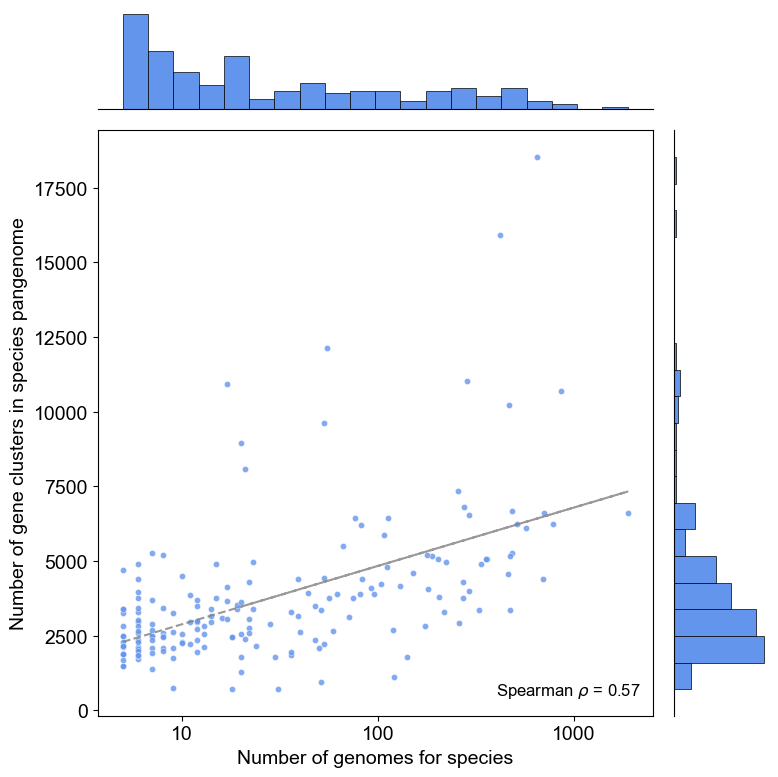

In [20]:
c = 90
    
temp = pangenome_counts[pangenome_counts['cluster_level'] == c]
temp['log_num_genomes'] = np.log10(temp['num_genomes'])
temp['log_VMGC_pangenome_size'] = np.log10(temp['VMGC_pangenome_size'])


# Square plot (4x4 inches)
g = sns.JointGrid(
    x="log_num_genomes",
    y="VMGC_pangenome_size",
    data=temp,
    height=8,
    ratio=5
)

# Scatterplot with size and alpha
g.plot_joint(sns.scatterplot, s=20, alpha=0.8,
             color='cornflowerblue')

# Marginal histograms
g.ax_marg_x.hist(temp['log_num_genomes'], 
                    bins=20,
                linewidth=0.5, edgecolor='black', color='cornflowerblue')
g.ax_marg_y.hist(temp['VMGC_pangenome_size'], 
                    bins=20, color='cornflowerblue',
                    orientation='horizontal', linewidth=0.5, edgecolor='black')

g.ax_marg_x.set_xticks([1,2,3], [10,100,1000])
# g.ax_marg_y.set_yticks([3,np.log10(5000),4], [10**3,5000,10**4])

# Remove ticks and spines on marginal histograms
g.ax_marg_x.tick_params(bottom=False, labelbottom=False)
g.ax_marg_y.tick_params(left=False, labelleft=False)
# sns.despine(ax=g.ax_marg_x, bottom=True, left=True)
# sns.despine(ax=g.ax_marg_y, bottom=True, left=True)

sns.despine(ax=g.ax_joint, top=False, right=False)


x = temp['log_num_genomes']
y = temp['VMGC_pangenome_size']

slope, intercept, r_value, p_value_lin, std_err = linregress(x, y)
regression_line = slope * x + intercept

# Plot the regression line
g.ax_joint.plot(x, regression_line, color='gray', linestyle='--', alpha=0.8)

correlation_coefficient, p_value = spearmanr(x, y)
g.ax_joint.annotate('Spearman ' + r'$\rho$' + f' = {round(correlation_coefficient,2)}',
                    xy=(2.6,500), fontsize=12)

g.ax_joint.set_xlabel('Number of genomes for species')
g.ax_joint.set_ylabel(f'Number of gene clusters in species pangenome')
fig_dir = '/Users/cdubin/Box/VMGC_cervical_dysplasia_paper/figures/'
plt.savefig(f'{fig_dir}/figure_1B.png', format='png', dpi=600, bbox_inches="tight")

plt.tight_layout()

### Add genome size

In [34]:
genome_metadata = pd.read_csv('/Users/cdubin/Library/CloudStorage/Box-Box/VMGC_cervical_dysplasia_paper/tables/Table_S1A.csv').set_index('species_code')
pangenome_counts['mean_num_bp_per_genome'] = pangenome_counts['VMGC_species_code'].map(genome_metadata['mean_num_bp_per_genome'])


In [33]:
print(pangenome_counts.head())

              species_name  VMGC_species_code  cluster_level  \
0  Acinetobacter baumannii             619896             75   
1  Acinetobacter baumannii             619896             80   
2  Acinetobacter baumannii             619896             85   
3  Acinetobacter baumannii             619896             90   
4  Acinetobacter baumannii             619896             95   

   VMGC_pangenome_size  num_genomes  mean_genome_size  
0                 4559            5         3503209.4  
1                 4592            5         3503209.4  
2                 4635            5         3503209.4  
3                 4691            5         3503209.4  
4                 4939            5         3503209.4  


/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_34076/597924144.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['log_num_genomes'] = np.log10(temp['num_genomes'])
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_34076/597924144.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['log_VMGC_pangenome_size'] = np.log10(temp['VMGC_pangenome_size'])
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_34076/597924144.py:6: SettingWithCopyWarning: 
A value is trying to be 

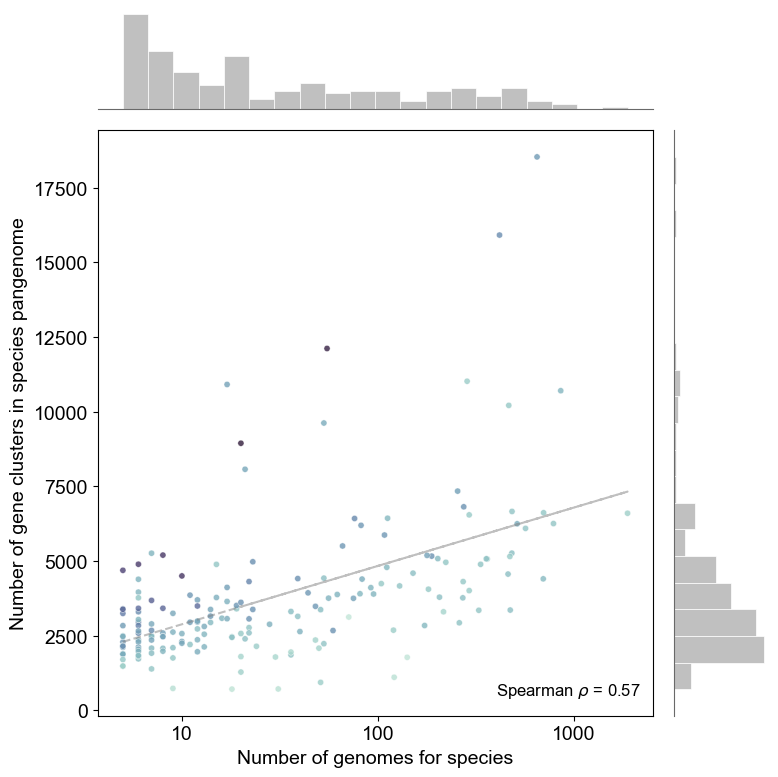

In [143]:
c = 90
    
temp = pangenome_counts[pangenome_counts['cluster_level'] == c]
temp['log_num_genomes'] = np.log10(temp['num_genomes'])
temp['log_VMGC_pangenome_size'] = np.log10(temp['VMGC_pangenome_size'])
temp['log_mean_num_bp_per_genome'] = np.log10(temp['mean_num_bp_per_genome'])


# Square plot (4x4 inches)
g = sns.JointGrid(
    x="log_num_genomes",
    y="VMGC_pangenome_size",
    data=temp,
    height=8,
    ratio=5, hue='mean_num_bp_per_genome'
)

# Scatterplot with size and alpha
g.plot_joint(sns.scatterplot, s=20, alpha=0.8,
            #  color='cornflowerblue', 
            palette=sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True)
, legend=False, vmin=4e5, vmax=4.5e6)

# Marginal histograms
g.ax_marg_x.hist(temp['log_num_genomes'], 
                    bins=20,
                linewidth=0.5, edgecolor='white', color='silver')
g.ax_marg_y.hist(temp['VMGC_pangenome_size'], 
                    bins=20, color='silver',
                    orientation='horizontal', linewidth=0.5, edgecolor='white')

g.ax_marg_x.set_xticks([1,2,3], [10,100,1000])
g.ax_marg_x.spines['bottom'].set_color('dimgrey')       

# Remove ticks and spines on marginal histograms
g.ax_marg_x.tick_params(bottom=False, labelbottom=False)
g.ax_marg_y.tick_params(left=False, labelleft=False)
g.ax_marg_y.spines['left'].set_color('dimgrey')       

# sns.despine(ax=g.ax_marg_x, bottom=True, left=True)
# sns.despine(ax=g.ax_marg_y, bottom=True, left=True)

sns.despine(ax=g.ax_joint, top=False, right=False)


# Plot the regression line
x = temp['log_num_genomes']
y = temp['VMGC_pangenome_size']

slope, intercept, r_value, p_value_lin, std_err = linregress(x, y)
regression_line = slope * x + intercept
g.ax_joint.plot(x, regression_line, color='gray', linestyle='--', alpha=0.5)
correlation_coefficient, p_value = spearmanr(x, y)
g.ax_joint.annotate('Spearman ' + r'$\rho$' + f' = {round(correlation_coefficient,2)}',
                    xy=(2.6,500), fontsize=12)

g.ax_joint.set_xlabel('Number of genomes for species')
g.ax_joint.set_ylabel(f'Number of gene clusters in species pangenome')
fig_dir = '/Users/cdubin/Box/VMGC_cervical_dysplasia_paper/figures/'
plt.savefig(f'{fig_dir}/figure_1B.png', format='png', dpi=600, bbox_inches="tight")

plt.tight_layout()

In [62]:
temp['mean_num_bp_per_genome'].min(), temp['mean_num_bp_per_genome'].max()

(489010.1971830986, 4275139.75)

In [110]:
custom_ticks

[500000.0,
 1000000.0,
 1500000.0,
 2000000.0,
 2500000.0,
 3000000.0,
 3500000.0,
 4000000.0,
 4500000.0]

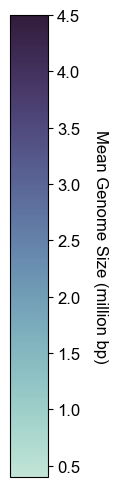

In [157]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(1, 6))
fig.subplots_adjust(right=0.5)

custom_ticks = [5e5, 1e6, 1.5e6, 2e6, 2.5e6, 3e6, 3.5e6, 4e6, 4.5e6]
# custom_labels =  ['', r'$1 \times 10^6$','', r'$2 \times 10^6$', '',r'$3 \times 10^6$', '',r'$4 \times 10^6$','' ]

norm = mpl.colors.Normalize(vmin=4e5, vmax=4.5e6) 

cb = fig.colorbar(
    mpl.cm.ScalarMappable(
        norm=norm, 
        cmap=sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True)
    ),
    cax=ax, 
    orientation='vertical'
)

cb.set_ticks(custom_ticks)
# cb.set_ticklabels(custom_labels)

cb.set_label('Mean Genome Size (million bp)', rotation=270, labelpad=20, fontsize=12)
cb.ax.tick_params(labelsize=12)
cb.ax.yaxis.get_offset_text().set_visible(False)

plt.savefig(f'{fig_dir}/figure_1B_colorbar.png', format='png', dpi=600, bbox_inches="tight")
plt.show()

In [96]:
norm

In [26]:
for c in [99, 95, 90, 85, 80, 75]:   

    temp = pangenome_counts[pangenome_counts['cluster_level'] == c]

    q = temp['VMGC_pangenome_size'].quantile([0.25, 0.75])


    print(f"Number of {c}% ANI gene clusters in pangenome:")
    print(f"median: {round(temp['VMGC_pangenome_size'].median())}, range: {temp['VMGC_pangenome_size'].min()}-{temp['VMGC_pangenome_size'].max()},  IQR: {round(q.loc[0.25])}-{round(q.loc[0.75])}")

Number of 99% ANI gene clusters in pangenome:
median: 7447, range: 881-162848,  IQR: 4223-14206
Number of 95% ANI gene clusters in pangenome:
median: 3626, range: 740-24294,  IQR: 2643-5351
Number of 90% ANI gene clusters in pangenome:
median: 3248, range: 713-18533,  IQR: 2358-4410
Number of 85% ANI gene clusters in pangenome:
median: 3081, range: 699-16818,  IQR: 2304-4091
Number of 80% ANI gene clusters in pangenome:
median: 2951, range: 691-15942,  IQR: 2274-3840
Number of 75% ANI gene clusters in pangenome:
median: 2907, range: 681-15379,  IQR: 2258-3728


In [27]:
temp['VMGC_pangenome_size'].quantile([0.25, 0.75])

0.25    2258.0
0.75    3727.5
Name: VMGC_pangenome_size, dtype: float64

/opt/anaconda3/envs/basics/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/opt/anaconda3/envs/basics/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/opt/anaconda3/envs/basics/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/opt/anaconda3/envs/basics/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/opt/anaconda3/envs/basics/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping

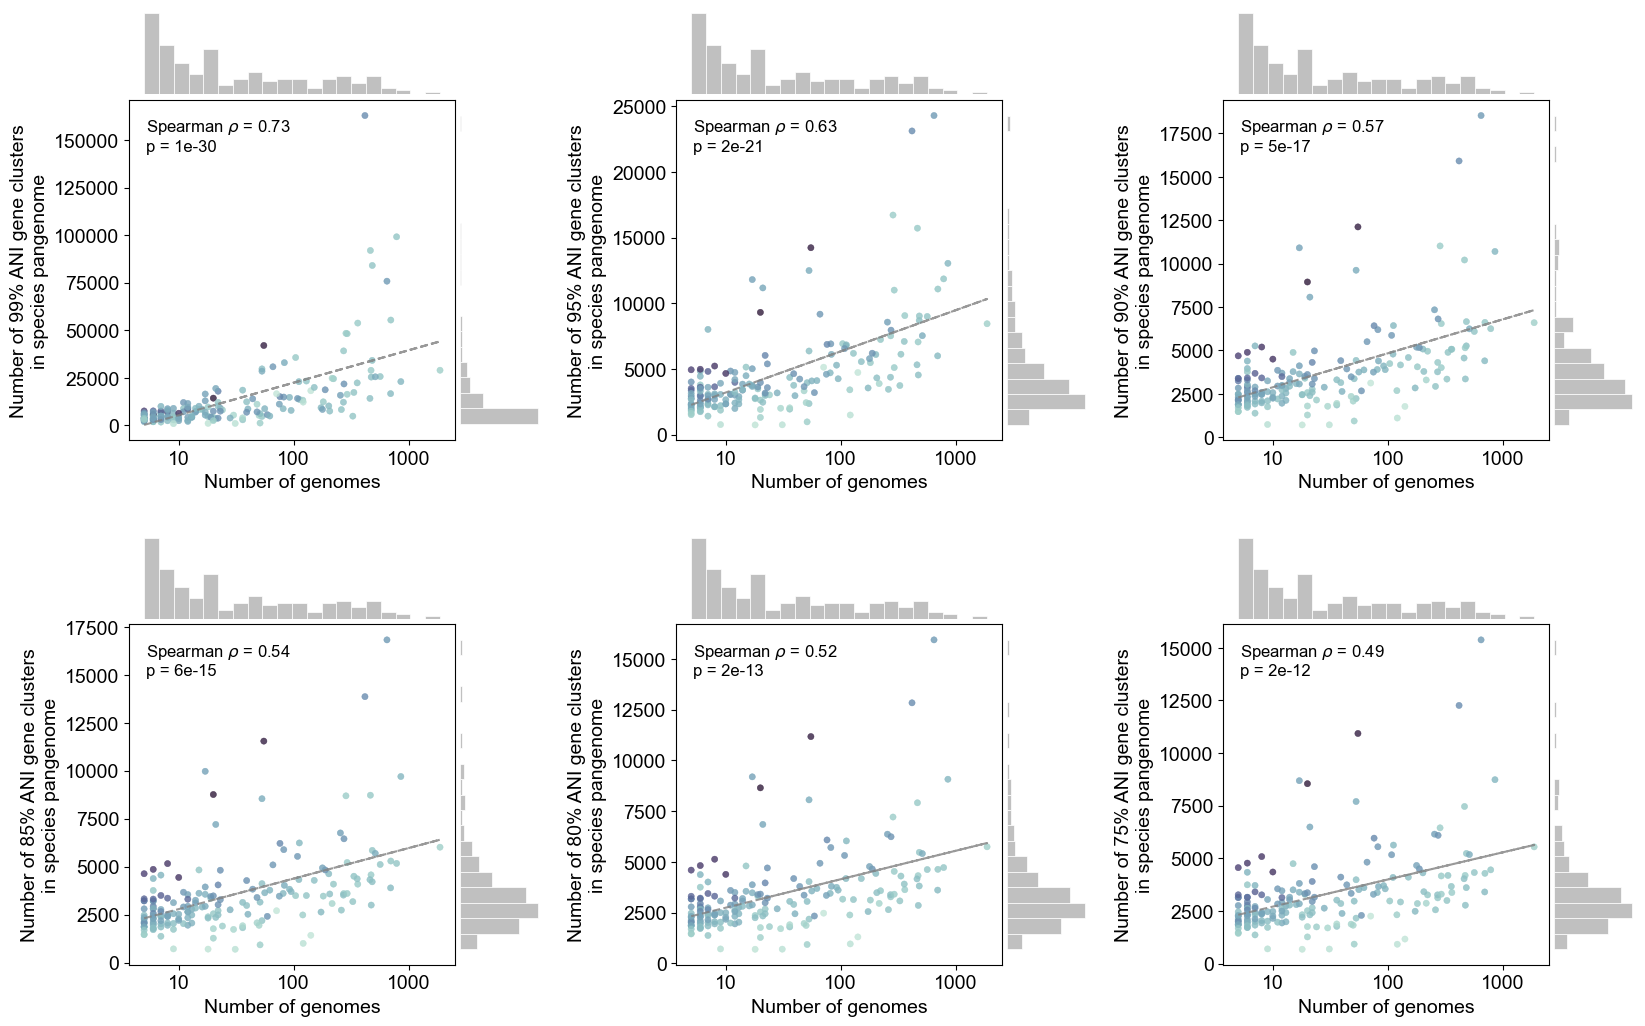

In [184]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from scipy.stats import linregress, spearmanr

# Setup the main figure
fig = plt.figure(figsize=(20, 13))

# Create an outer grid for the 6 subplots (2 rows, 3 columns)
outer_grid = gridspec.GridSpec(2, 3, figure=fig, wspace=0.2, hspace=0.1)

cluster_levels = [99, 95, 90, 85, 80, 75]

for i, c in enumerate(cluster_levels):
    # Filter data
    temp = pangenome_counts[pangenome_counts['cluster_level'] == c].copy()
    temp['log_num_genomes'] = np.log10(temp['num_genomes'])
    # Note: You calculated log_VMGC but plotted the linear VMGC in your original code, 
    # so I am sticking to linear Y for consistency.
    
    # Create an inner grid for this specific subplot (to hold scatter + marginals)
    # width_ratios and height_ratios mimic the JointGrid 'ratio=5'
    inner_grid = gridspec.GridSpecFromSubplotSpec(4, 4, subplot_spec=outer_grid[i],
                                                  width_ratios=[4, 1, 0.2, 0.2], 
                                                  height_ratios=[1, 4, 0.2, 0.2],
                                                  wspace=0.05, hspace=0.05)
    
    # Create the axes for Scatter (main), Hist X (top), and Hist Y (right)
    ax_joint = fig.add_subplot(inner_grid[1, 0])
    ax_marg_x = fig.add_subplot(inner_grid[0, 0], sharex=ax_joint)
    ax_marg_y = fig.add_subplot(inner_grid[1, 1], sharey=ax_joint)

    # 1. Main Scatter Plot
    sns.scatterplot(x='log_num_genomes', y='VMGC_pangenome_size', data=temp, hue='mean_num_bp_per_genome',
                    s=20, alpha=0.8,  ax=ax_joint, edgecolor=None,  
                    palette=sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True), legend=False, vmin=4e5, vmax=4.5e6)

    # # 2. Marginal Histograms
    # ax_marg_x.hist(temp['log_num_genomes'], bins=20, 
    #                linewidth=0.5, edgecolor='black', color='cornflowerblue')
    # ax_marg_y.hist(temp['VMGC_pangenome_size'], bins=20, 
    #                orientation='horizontal', linewidth=0.5, edgecolor='black', color='cornflowerblue')


    ax_marg_x.hist(temp['log_num_genomes'], 
                        bins=20,
                    linewidth=0.5, edgecolor='white', color='silver')
    ax_marg_y.hist(temp['VMGC_pangenome_size'], 
                        bins=20, color='silver',
                        orientation='horizontal', linewidth=0.5, edgecolor='white')
    
    ax_marg_x.tick_params(axis='both', left=False, labelleft=False, bottom=False, labelbottom=False)
    ax_marg_y.tick_params(axis='both', left=False, labelleft=False, bottom=False, labelbottom=False)
    

    # ax_marg_x.set_xticks([1,2,3], [10,100,1000])
    # ax_marg_x.spines['bottom'].set_color('dimgrey')       

    # Remove ticks and spines on marginal histograms
    # ax_marg_x.tick_params(bottom=False, labelbottom=False)
    # ax_marg_y.tick_params(left=False, labelleft=False)
    ax_marg_y.spines['left'].set_color('dimgrey')       


    sns.despine(ax=ax_joint, top=False, right=False)


    x = temp['log_num_genomes']
    y = temp['VMGC_pangenome_size']
    
    slope, intercept, r_value, p_value_lin, std_err = linregress(x, y)
    regression_line = slope * x + intercept
    ax_joint.plot(x, regression_line, color='gray', linestyle='--', alpha=0.8)

    correlation_coefficient, p_value = spearmanr(x, y)
    
    to_annotate = f'Spearman $\\rho$ = {round(correlation_coefficient, 2)}\n'
    to_annotate += f'p = {p_value:.0e}'
    
    # Dynamic positioning for annotation (top left of the scatter area)
    y_lims = ax_joint.get_ylim()
    # x_lims = ax_joint.get_xlim()
    ax_joint.annotate(to_annotate, xy=(0.05, 0.85), xycoords='axes fraction', 
                      fontsize=12, horizontalalignment='left')

    
    # Remove spines for marginals to look like JointGrid
    sns.despine(ax=ax_marg_x, left=True, bottom=True, right=True, top=True) # clean look
    sns.despine(ax=ax_marg_y, left=True, bottom=True, right=True, top=True)
    sns.despine(ax=ax_joint, top=False, right=False) # Keep box around scatter if desired, or set True

    # 5. Set Labels and Custom Ticks
    ax_joint.set_xticks([1, 2, 3])
    ax_joint.set_xticklabels([10, 100, 1000])
    
    ax_joint.set_xlabel('Number of genomes', fontsize=14)
    ax_joint.set_ylabel(f'Number of {c}% ANI gene clusters\nin species pangenome', fontsize=14)
    # ax_joint.set_title(f'Cluster Level: {c}', fontsize=14, loc='left', y=1.2)

# Adjust layout
# plt.tight_layout() # Careful with tight_layout and GridSpec, usually manual spacing in GridSpec is safer
plt.savefig(f'{fig_dir}/figure_S1.png', format='png', dpi=600, bbox_inches="tight")
plt.show()

/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_69090/582938726.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['log_num_genomes'] = np.log10(temp['num_genomes'])
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_69090/582938726.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['log_VMGC_pangenome_size'] = np.log10(temp['VMGC_pangenome_size'])
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_69090/582938726.py:4: SettingWithCopyWarning: 
A value is trying to be 

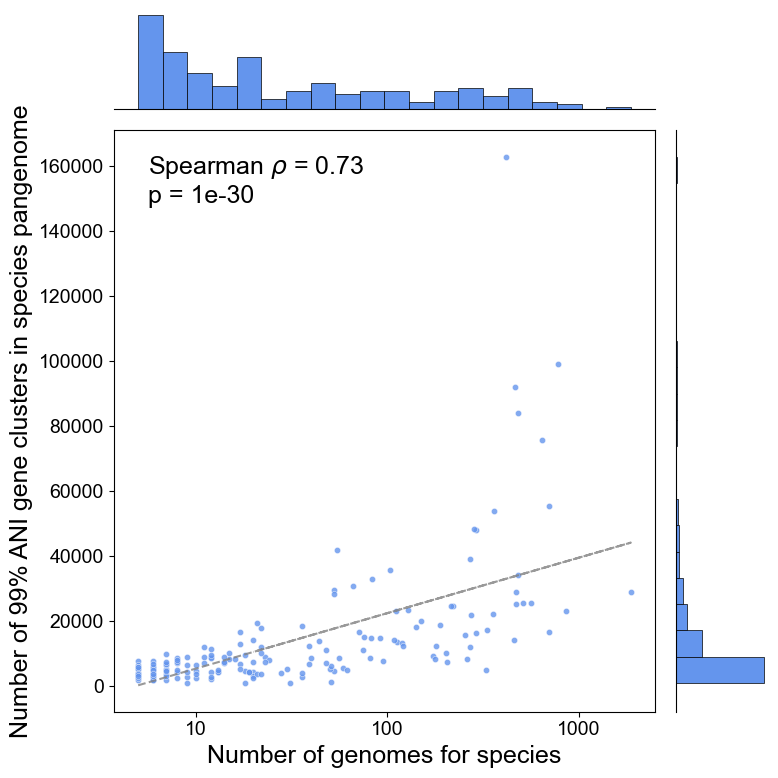

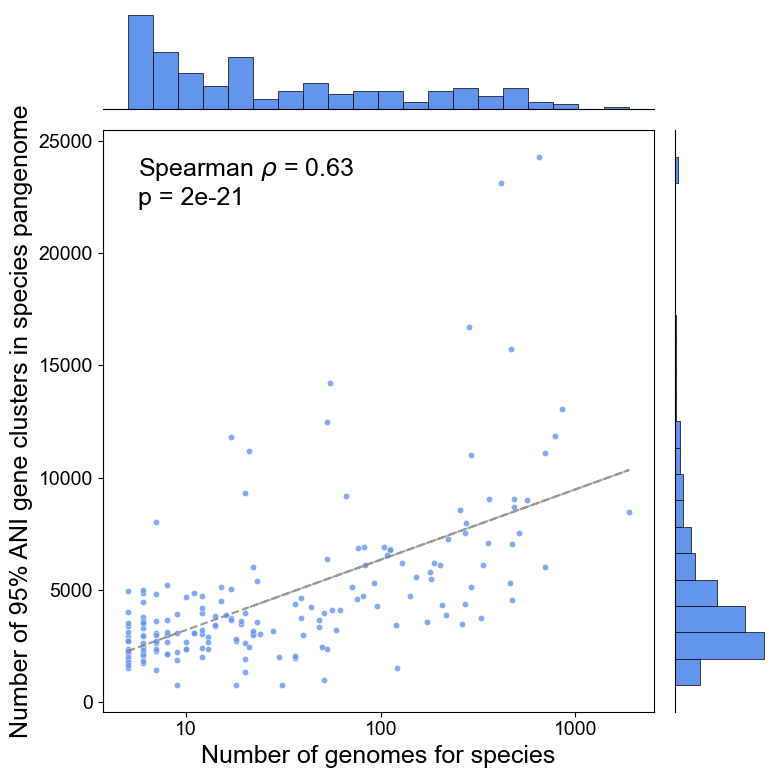

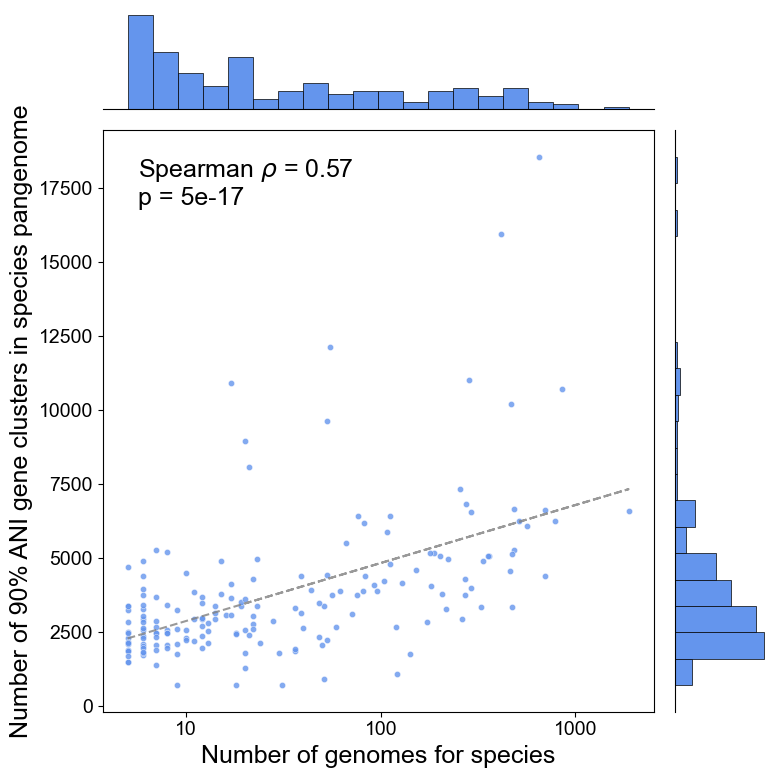

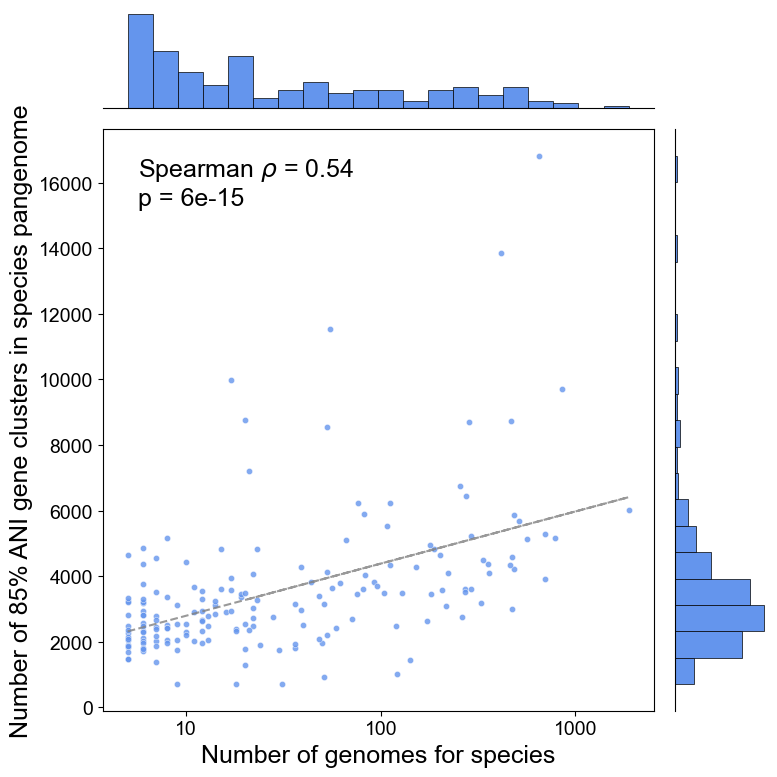

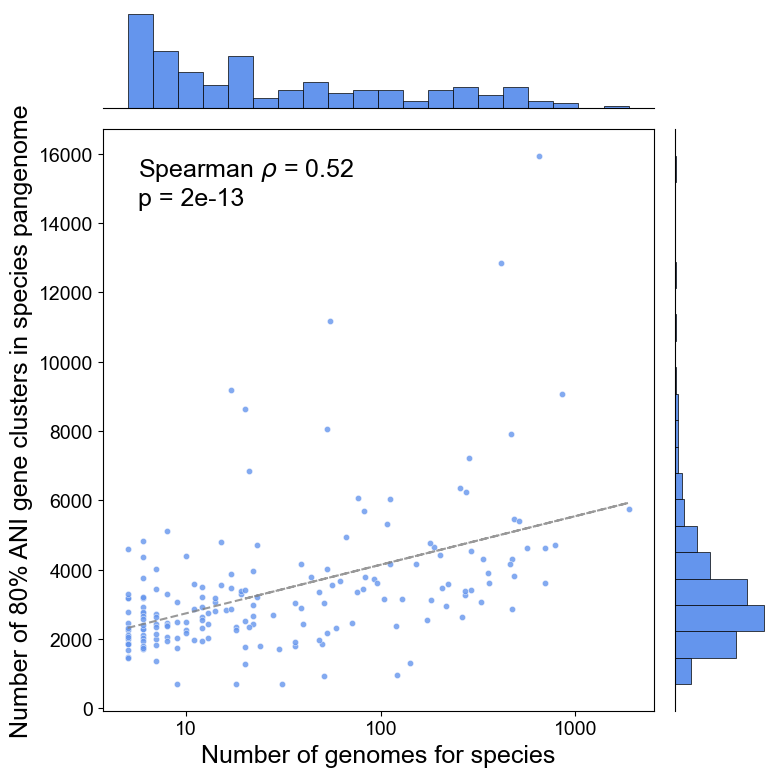

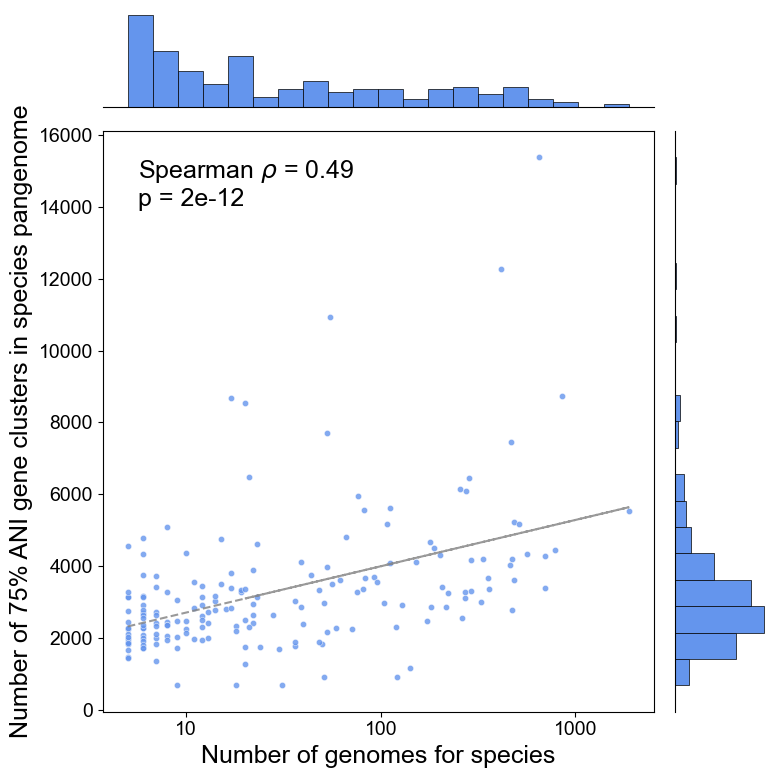

In [28]:
for c in [99, 95, 90, 85, 80, 75]:   

    temp = pangenome_counts[pangenome_counts['cluster_level'] == c]
    temp['log_num_genomes'] = np.log10(temp['num_genomes'])
    temp['log_VMGC_pangenome_size'] = np.log10(temp['VMGC_pangenome_size'])

    # Square plot (4x4 inches)
    g = sns.JointGrid(
        x="log_num_genomes",
        y="VMGC_pangenome_size",
        data=temp,
        height=8,
        ratio=5
    )

    # Scatterplot with size and alpha
    g.plot_joint(sns.scatterplot, s=20, alpha=0.8,
                color='cornflowerblue')

    # Marginal histograms
    g.ax_marg_x.hist(temp['log_num_genomes'], 
                        bins=20,
                    linewidth=0.5, edgecolor='black', color='cornflowerblue')
    g.ax_marg_y.hist(temp['VMGC_pangenome_size'], 
                        bins=20, color='cornflowerblue',
                        orientation='horizontal', linewidth=0.5, edgecolor='black')

    g.ax_marg_x.set_xticks([1,2,3], [10,100,1000])
    # g.ax_marg_y.set_yticks([3,np.log10(5000),4], [10**3,5000,10**4])

    # Remove ticks and spines on marginal histograms
    g.ax_marg_x.tick_params(bottom=False, labelbottom=False)
    g.ax_marg_y.tick_params(left=False, labelleft=False)
    # sns.despine(ax=g.ax_marg_x, bottom=True, left=True)
    # sns.despine(ax=g.ax_marg_y, bottom=True, left=True)

    sns.despine(ax=g.ax_joint, top=False, right=False)


    x = temp['log_num_genomes']
    y = temp['VMGC_pangenome_size']

    slope, intercept, r_value, p_value_lin, std_err = linregress(x, y)
    regression_line = slope * x + intercept

    # Plot the regression line
    g.ax_joint.plot(x, regression_line, color='gray', linestyle='--', alpha=0.8)

    correlation_coefficient, p_value = spearmanr(x, y)

    # to_annotate = 'Spearman ' + r'$\rho$' + f' = {round(correlation_coefficient,2)}'

    # to_annotate += '$\n \it{p}}$' 
    # to_annotate += f'{"{:.0e}".format(p_value)}'

    # g.ax_joint.annotate(to_annotate,
    #                     xy=(2.6,500), fontsize=12)
    to_annotate = f'Spearman $\\rho$ = {round(correlation_coefficient, 2)}\n'
    # to_annotate += f'$\\mathit{{p}}$ = {p_value:.0e}'
    to_annotate += f'p = {p_value:.0e}'

    g.ax_joint.annotate(to_annotate, xy=(.75, g.ax_joint.get_ylim()[1]*0.87), fontsize=18, horizontalalignment='left')
    g.ax_joint.tick_params(axis='y', which='major', labelsize=14)

    g.ax_joint.set_xlabel('Number of genomes for species', fontsize=18)
    g.ax_joint.set_ylabel(f'Number of {c}% ANI gene clusters in species pangenome', fontsize=18)
    # plt.savefig(f'/Users/cdubin/Desktop/pangenome_size_{c}.png', format='png', dpi=600, bbox_inches="tight")

    plt.tight_layout()